# Modelling

This document follows the data cleaning and scraping by modelling the footfall data. The model is selected, tuned and fitted using the footfall data between 2019 and 2024. The model is then used later on to predict the 2025 footfall, to allow event evaluation.

The below steps are followed:

### 1) Model selection

The performance of four different machine learning models is tested using 10-fold cross validation. The models include:

* Linear regression
* Random Forest
* XGBoost
* Extra Trees Regressor

The outputs of the 10-fold cross validation process are used to calculate the error metric scores associated with that model (averaged over all folds). The MAE, the MAPE, the R2 and the RMSE metrics are compared to find the model that will best fit the data.

**Conclusion:** Random Forest Regression is the best performing model. After going through model selection **and** conducting model evaluation.

### 2) Model Evaluation

The performance of the model is tested, using a 80-20 test split with the chronological order of the data preserved. The model performance is evaluated using the error metrics of MAE, MAPE, R2 and RMSE.

### 3) Hyperparameter Tuning


Hyperparameter tuning is performed as it allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. 

### 4) Fitting the Final Model

Using the optimal hyperparameters found during the tuning, the model is fitted again, this time using the whole dataset (no training and test splits).

### 5) Feature Importance

The feature importance of the model predictor variables is investigated.

### 5) Cross-Validated SHAP for Feature Importance

The feature importance of the model predictor variables is investigated using SHAP.

### 7) Using Model to Evaluate Events (Recursive Forecasting)

The final model is used to quantify the change in footfall that would otherwise been predicted in 2025.

In [279]:
pip install matplotlib geopandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [280]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

Here the data used to train and evaluate the models only contains the footfall data from 2019 to 2024.

In [281]:
#Load training footfall (2019-2024) data
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - All areas\footfall_cleaned_19_24")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8780 entries, 0 to 8779
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         8780 non-null   int64  
 1   datestamp                          8780 non-null   object 
 2   estimated_actual_footfall          8780 non-null   float64
 3   estimated_actual_footfall_rolling  8612 non-null   float64
 4   year                               8780 non-null   int64  
 5   month                              8780 non-null   int64  
 6   monthday                           8780 non-null   int64  
 7   weekday                            8780 non-null   int64  
 8   week_of_year                       8780 non-null   int64  
 9   Sin_weekday                        8780 non-null   float64
 10  Cos_weekday                        8780 non-null   float64
 11  Sin_monthday                       8780 non-null   float

In [282]:
data.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7,area_name,area_Bradford - City Centre,area_Bradford BID,area_Lister Park,area_Met Office - Bradford
0,0,2019-01-01,63656.86,NaN,2019,1,1,1,1,0.866025,...,NaN,NaN,NaN,NaN,NaN,Bradford - City Centre,1,0,0,0
1,1,2019-01-01,95485.29,NaN,2019,1,1,1,1,0.866025,...,NaN,NaN,NaN,NaN,NaN,Bradford BID,0,1,0,0
2,2,2019-01-01,12821.68,NaN,2019,1,1,1,1,0.866025,...,NaN,NaN,NaN,NaN,NaN,Lister Park,0,0,1,0
3,3,2019-01-01,530996.00,NaN,2019,1,1,1,1,0.866025,...,NaN,NaN,NaN,NaN,NaN,Met Office - Bradford,0,0,0,1
4,4,2019-01-02,133008.44,NaN,2019,1,2,2,1,0.866025,...,63656.86,NaN,NaN,NaN,NaN,Bradford - City Centre,1,0,0,0


In [283]:
#For time series analysis, the data needs to be in chronological order
# thus there is a need to reset the indexes based on datestamp
data = data.sort_values('datestamp')
data = data.reset_index(drop=True)

In [284]:
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'weekday', 'week_of_year', 'monthday', 'datestamp', 'area_name'], axis=1, inplace=True)
data.head()

,estimated_actual_footfall,estimated_actual_footfall_rolling,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,...,daylight_duration,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7,area_Bradford - City Centre,area_Bradford BID,area_Lister Park,area_Met Office - Bradford
0,63656.86,NaN,2019,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,...,27067.838,NaN,NaN,NaN,NaN,NaN,1,0,0,0
1,95485.29,NaN,2019,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,...,27067.838,NaN,NaN,NaN,NaN,NaN,0,1,0,0
2,12821.68,NaN,2019,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,...,27067.838,NaN,NaN,NaN,NaN,NaN,0,0,1,0
3,530996.00,NaN,2019,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,...,27067.838,NaN,NaN,NaN,NaN,NaN,0,0,0,1
4,133008.44,NaN,2019,0.866025,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,...,27147.844,63656.86,NaN,NaN,NaN,NaN,1,0,0,0


In [285]:
#Chek NAs and drop rows with no footfall information
print(data['estimated_actual_footfall'].isna().sum())
data = data.dropna(subset=['estimated_actual_footfall'])
print(data['estimated_actual_footfall'].isna().sum())

0
0


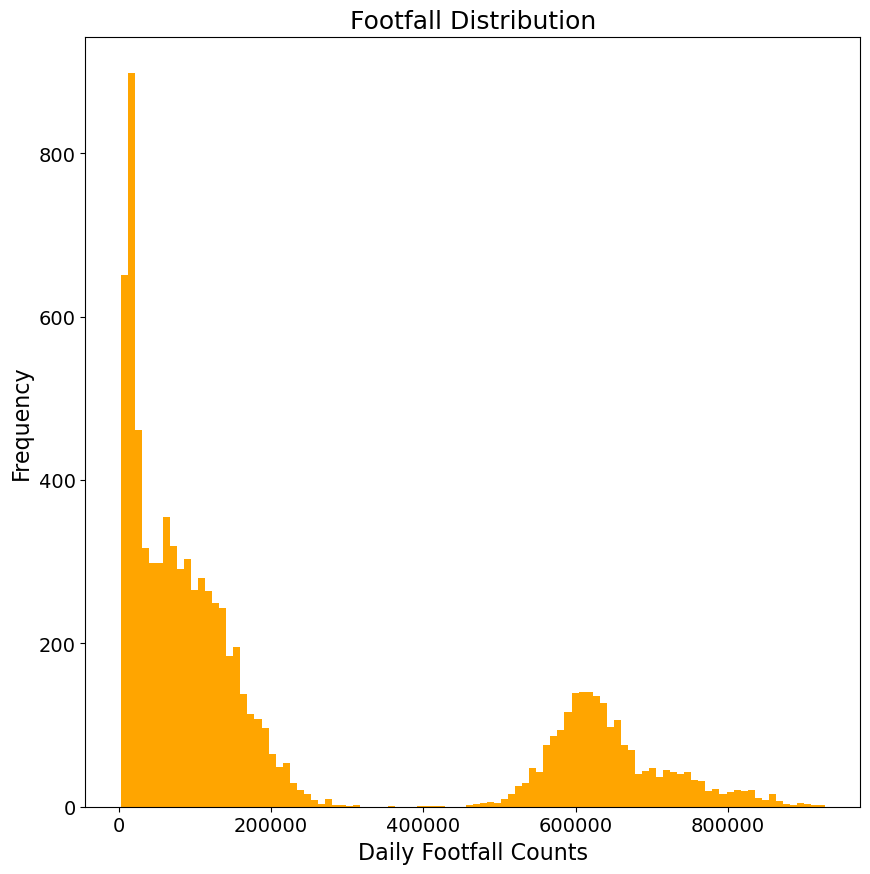

In [286]:
#Plot distribution of footfall counts
plt.figure(figsize=(10, 10))
plt.hist(data.estimated_actual_footfall, bins=100, color='orange')
plt.title('Footfall Distribution', fontsize=18)
plt.xlabel('Daily Footfall Counts', fontsize= 16)
plt.ylabel('Frequency', fontsize=16)
plt.tick_params(axis='both', labelsize= 14)
ax = plt.gca()  #get axes
ax.xaxis.get_offset_text().set_fontsize(14)
plt.show()

Explore relationship between variables.

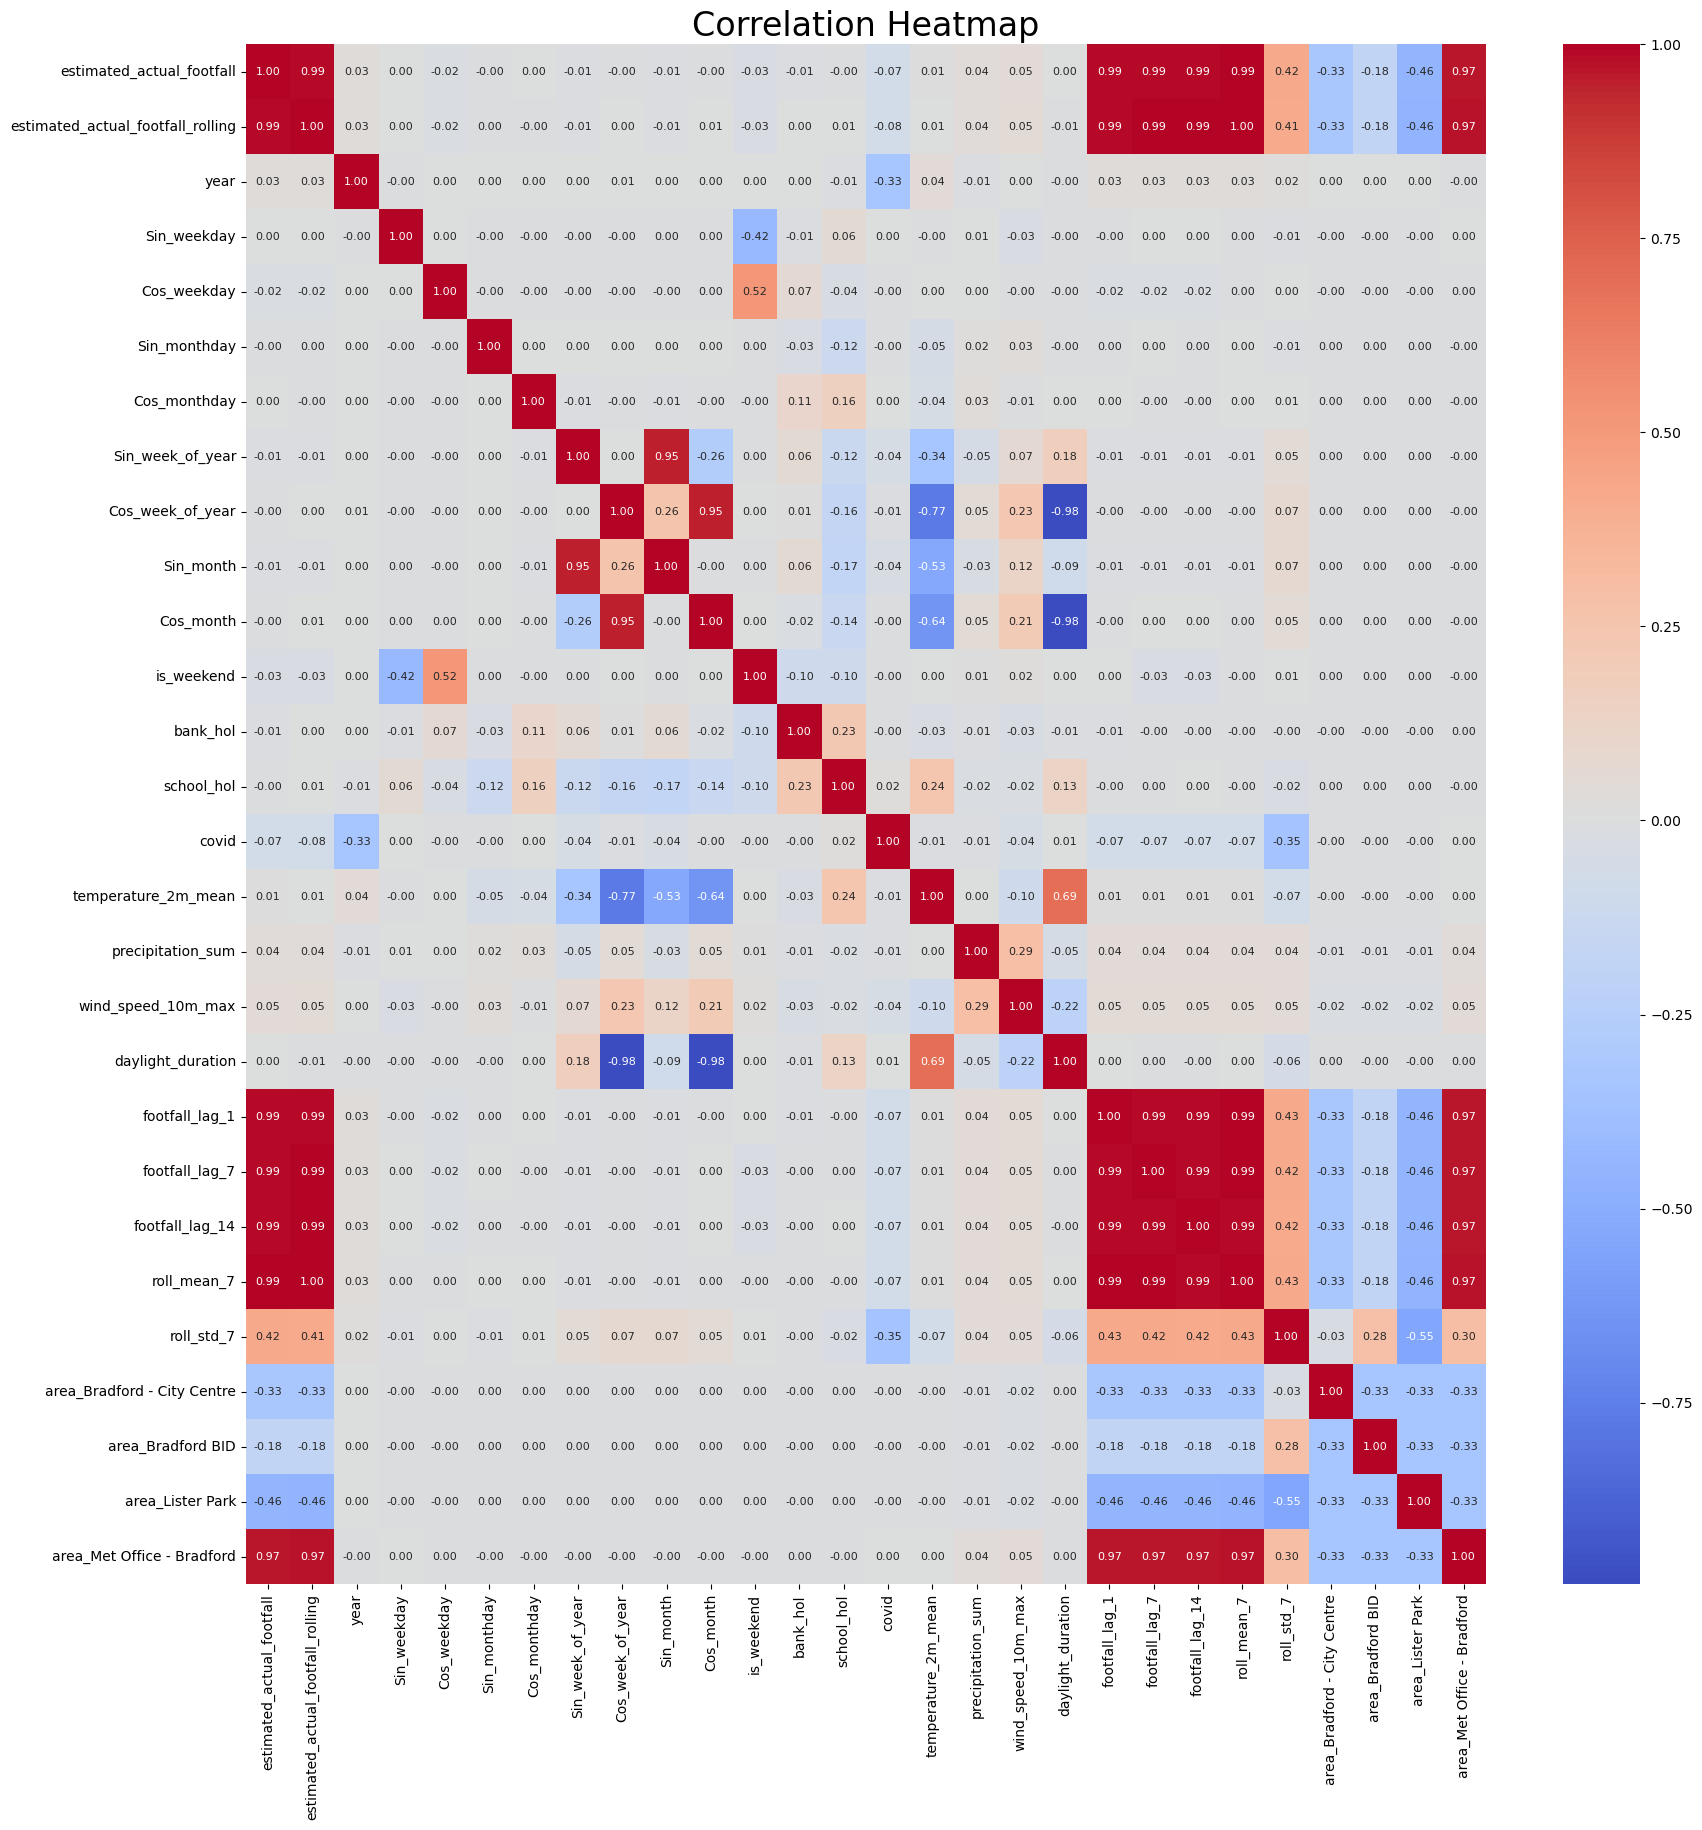

In [287]:
#Correlation Heatmap
plt.figure(figsize=(20, 20))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")
plt.title('Correlation Heatmap', fontsize=24)
plt.show()

# 1- Model Selection

In [288]:
!pip install xgboost
!pip install scikit-learn==1.4.2

In [289]:
!pip install scikit-learn

In [290]:
#Load packages
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate
from time import time

In [291]:
#Prepare data for modelling

def prepare_x_y_data(input_data):
    data = input_data.copy()
    # Fill any missing values
    data = data.fillna(0)
    
    # Add a random variables (to compare performance of other variables against)
    #rng = np.random.RandomState(seed=42)
    #data['random'] = np.random.random(size=len(data)) #continuous random variable between 0 and 1
    #data["random_cat"] = rng.randint(3, size=data.shape[0]) #categorical random variable, integer is either 0, 1 or 2

    # Prepare data for modelling 
    # Split into predictor/predictand variables
    Xfull = data.drop(['estimated_actual_footfall'], axis =1) #Predictor variables
    Yfull = data['estimated_actual_footfall'].values #target variable

    return Xfull, Yfull

# Run function
Xfull, Yfull = prepare_x_y_data(data)

In [ ]:
print("Running models with explanatory variables: ", Xfull.columns)

Running models with explanatory variables:  Index(['estimated_actual_footfall_rolling', 'year', 'Sin_weekday',
       'Cos_weekday', 'Sin_monthday', 'Cos_monthday', 'Sin_week_of_year',
       'Cos_week_of_year', 'Sin_month', 'Cos_month', 'is_weekend', 'bank_hol',
       'school_hol', 'covid', 'temperature_2m_mean', 'precipitation_sum',
       'wind_speed_10m_max', 'daylight_duration', 'footfall_lag_1',
       'footfall_lag_7', 'footfall_lag_14', 'roll_mean_7', 'roll_std_7',
       'area_Bradford - City Centre', 'area_Bradford BID', 'area_Lister Park',
       'area_Met Office - Bradford'],
      dtype='object')


Run the 4 models with cross-validation

Define the error metrics for the cross-validation to return, and the parameters of the cross validation


In [293]:
#Define error metrics
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']
#Split the data into 10 folds, shuffle=True ensures randomization
cv_parameters = KFold(n_splits=10, random_state=1, shuffle=True)

In [294]:
# Create dataframe to store the scores for all the models
error_metric_scores = pd.DataFrame()

In [295]:
#Create the 4 models
lr_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['linear_regressor',LinearRegression()]])
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
xgb_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['xgb_regressor',xgb.XGBRegressor(random_state=1, n_jobs = 16)]])
et_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['et_regressor',ExtraTreesRegressor (random_state = 1, n_jobs = 16)]])

#Create dictionary to contain model results
models_dict = {"linear_regressor": lr_model_pipeline, 
               "xgb_regressor":xgb_model_pipeline,
               "rf_regressor":rf_model_pipeline,
               "et_regressor": et_model_pipeline}

In [296]:
# Run models with 10 fold cross validation

for model_name, model_pipeline in models_dict.items():
    print(model_name)
    # Use cross_validate to return the error scores associated with this model and this data
    start = time()
    model_output = cross_validate(model_pipeline, Xfull, Yfull, cv=cv_parameters, scoring=error_metrics, error_score="raise")

    end = time()
    print('Ran in {} minutes'.format(round((end - start)/60),2)) #how long model took to run
    
    # Formulate the different error scores into a dataframe
    error_metrics_df =pd.DataFrame({'mae': round(abs(model_output['test_neg_mean_absolute_error'].mean()),2), 
                  'mape': round(abs(model_output['test_neg_mean_absolute_percentage_error'].mean()),2),
                  'r2': round(abs(model_output['test_r2'].mean()),2), 
                  'rmse': round(abs(model_output['test_neg_root_mean_squared_error'].mean()),2)},
                 index =[model_name])
        
    # Add evaluation metric scores for this model to the dataframe containing the metrics for each model
    error_metric_scores = pd.concat([error_metric_scores, error_metrics_df])

linear_regressor
Ran in 0 minutes
xgb_regressor
Ran in 0 minutes
rf_regressor
Ran in 0 minutes
et_regressor
Ran in 0 minutes


In [297]:
#Check results
error_metric_scores.head()

,mae,mape,r2,rmse
linear_regressor,20789.91,0.33,0.99,30261.31
xgb_regressor,20265.08,0.29,0.99,29243.49
rf_regressor,20135.21,0.29,0.99,28943.68
et_regressor,19716.40,0.28,0.99,28536.54


**Results**:
* Mean Absolute Error: ExtraTree Regressor has the best accuracy (lowest mae)
* Mean Absolute Percentage Error: ExtraTree Regressor have the best accuracy (lowest mape)
* R-Squared: several models has the best accuracy (highest r2)
* Root Mean Squared Error: ExtraTree Regressor has the best accuracy (lowest rmse)

Conclusion: ExtraTree Regressor is the best performing model.

However, when running the below model evaluation, with 80/20 split of data by chronological order and TimeSeriesSplit in tuning, **the Random Forest Regressor outperforms the ExtraTree Regressor. Thus, Random Forest Regressor is chosen.**


Random Forest Regression Evaluation Results:
* Mean absolute error: [np.float64(23407.295396241458)]
* Mean R2: [np.float64(0.9820518972311367)]
* Mean RMSE: [np.float64(31927.703566909764)]

ExtraTree Regressor Evaluation Results:
* Mean absolute error: [np.float64(26227.058201309796)]
* Mean R2: [np.float64(0.9771602914975207)]
* Mean RMSE: [np.float64(36016.680822781585)]

# 2- Evaluating the Random Forest Regression model

The first 80% of the data is used for training, and the last 20% for testing. Potential issues: the final portion of time might exhibit different patterns to the rest of the time.

As we are analysing time series data, we cannot choose random samples and assign them to either the test set or the train set because it doesn't make sense to use values from the future to forecast the past. There is a temporal dependency between observations, and this must be preserved during testing.

So, need to ensure that the test set always has a later time stamp than the training set.

In [298]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

In [299]:
# Custom function for neg_mean_absolute_percentage_error
def neg_mean_absolute_percentage_error(y_true, y_pred):
    return -100 * np.mean(np.abs((y_true - y_pred) / y_true))

In [300]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [301]:
# Set up model pipeline
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
model_dict = {"rf_regressor":rf_model_pipeline}

Get testing and training data

In [302]:
Xfull, Yfull = prepare_x_y_data(data)
dates = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - All areas\footfall_cleaned_19_24")['datestamp']

In [303]:
# Create train/test index lists based on a 80/20 split of data by chronological order
train_index = Xfull[0:int(len(Xfull)*0.8)].index.tolist()
test_index = Xfull[int(len(Xfull)*0.8):].index.tolist()

In [304]:
# Lists to store the error metric scores
mae_scores = []
rmse_scores= []
r2_scores= []
neg_mae_scores = []
# Lists to store predicted and actual values
predicted_values=[]
observed_values = []
# List to store the dates
dates_used = []

In [305]:
start = time()

# Get train and testing data for this fold
print(f"train index: {len(train_index)}")
print(f"test index: {len(test_index)}")
print(f"percentage of data used as testing: {round(len(test_index)/len(train_index)*100,1)}")

X_train, X_test = Xfull.iloc[train_index], Xfull.iloc[test_index]
y_train, y_test = Yfull[train_index], Yfull[test_index]

# Fit the model on the training data
rf_model_pipeline.fit(X_train, y_train)
# Use it to make predictions on the testing data, and store these
y_pred = rf_model_pipeline.predict(X_test)
predicted_values.append(y_pred)
# Store the datetimes
dates_used.append(dates[train_index])
# Store the actual values for the testing data
observed_values.append(y_test)
# Calculate the error metrics for this fold and append to the scores lists
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
rmse_scores.append(root_mean_squared_error(y_test, y_pred))
neg_mae_scores = [-score for score in mae_scores]        

end = time()
#Get time it took to run model in full
print('Ran cross_val_predict in {} minutes'.format(round((end - start)/60),2))

train index: 7024
test index: 1756
percentage of data used as testing: 25.0
Ran cross_val_predict in 0 minutes


In [306]:
# Store lists of predicted and observed values
predicted_values_all = []
observed_values_all= []
for i in range(len(predicted_values)):
    for j in range(len(predicted_values[i])):
        observed_values_all.append(observed_values[i][j])
        predicted_values_all.append(predicted_values[i][j])

In [307]:
# Print evaluation metrics
print(f"Mean absolute error: {mae_scores}")
print(f"Mean R2: {r2_scores}")
print(f"Mean RMSE: {rmse_scores}")

Mean absolute error: [np.float64(23407.295396241458)]
Mean R2: [np.float64(0.9820518972311367)]
Mean RMSE: [np.float64(31927.703566909764)]


**Results:**
The Mean Absolute Error and Mean RMSE are quite good, indicating there is on average a difference of BLA and BLA footfall counts between predicted and observed values.The Mean R-Squared is high, indicating the model is good at explaining footfall variability.

There is a need to tune the model's hyperparameters to improve the scores.

# 3- Hyperparameters Tuning with RandomizedSearchCV
Hyperparameter tuning allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. The Randomized Search exhaustively searches through all possible combinations of parameters provided in the param_grid.

The TimeSeriesSplit allows cross-validation for time series data, as future data should not be used to predict past data and random splits can cause data leakage. TimeSeriesSplit ensures that the training set comes before the test set.

As the model fitting is manually done here, the X values need to be scaled manually, whereas they were previously within the model pipeline.

In [308]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [309]:
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state= 1))])

In [310]:
#Create HyperParameter grid
param_grid = {
    'rf__n_estimators': [50, 100, 150, 200, 250, 300], #number of trees
    'rf__max_depth': [10, 20, 30, 40, None], #maximum depth of each tree
    'rf__min_samples_split': [2, 5, 10], #minimum n° of samples required to split a node
    'rf__min_samples_leaf': [1, 2, 4], #minimum samples at leaf node
    'rf__max_features': ['sqrt', 'log2', None], #n° of features to consider per split
    'rf__bootstrap': [True, False]
}

Warning: the following code takes 45min to run

In [311]:
#Find the best hyperparameters settings for this model
#from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

#TimeSeriesSplit CV
#tscv= TimeSeriesSplit(n_splits= 5)

#rfr_Rsearch = RandomizedSearchCV(estimator= rf_model, 
                            #param_distributions=param_grid, 
                            #cv= tscv, 
                            #verbose=2, 
                            #n_iter=100, 
                            #random_state=1,
                            #n_jobs= 1,
                            #scoring= 'neg_mean_absolute_error',
                            #return_train_score= True
                            #)
#rfr_Rsearch.fit(X_train, y_train)

#Display best hyperparameters
#print('Best hyperparameters:', rfr_Rsearch.best_params_)
#print('Best score', -rfr_Rsearch.best_score_)

Results:Best hyperparameters: {'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': None, 'rf__max_depth': 10, 'rf__bootstrap': True}
Best score 20785.630476180442

In [312]:
#Evaluate the holdout test set
#Make predictions
#y_pred = rfr_Rsearch.best_estimator_.predict(X_test)

#Use predictions to evaluate model
#mae = mean_absolute_error(y_test, y_pred)
#r2 = r2_score(y_test, y_pred)
#rmse = root_mean_squared_error(y_test, y_pred)
#mape = mean_absolute_percentage_error(y_test, y_pred)

# Print evaluation metrics
#print(f"MAE: {mae}")
#print(f"R2: {r2}")
#print(f"RMSE: {rmse}")
#print(f"MAPE: {mape}")

Results:
* MAE: 23062.384084833942
* R2: 0.9826358106774546
* RMSE: 31404.050347068856
* MAPE: 0.2801072387336122

## Plot predicted vs actual values

In [313]:
pip install datashader

Note: you may need to restart the kernel to use updated packages.


In [314]:
import datashader as ds
from datashader.mpl_ext import dsshow

# Code from: https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density-in-matplotlib/53865762#53865762
def using_datashader(ax, x, y, normalisation):
    df = pd.DataFrame(dict(x=x, y=y))
    dsartist = dsshow(df,ds.Point("x", "y"),ds.count(), vmin=0.1, vmax=100,norm=normalisation,aspect="auto",ax=ax)
    cbar = plt.colorbar(dsartist, ax=ax)
    cbar.ax.tick_params(labelsize=10) 

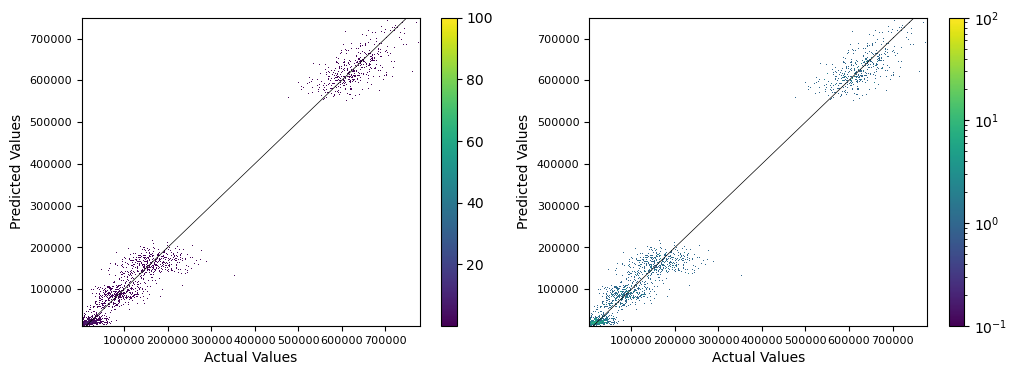

In [315]:
#Plot log and linear scales

import datashader as ds
from datashader.mpl_ext import dsshow
fig, axs = plt.subplots(ncols=2, figsize = (12,4))

# Plot with linear scale
using_datashader(axs[0], y_test, predicted_values_all, 'linear')
axs[0].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[0].set_ylabel("Predicted Values", size=10)
axs[0].set_xlabel("Actual Values", size=10)
# axs[0].set_xlim([0, 2000])
# axs[0].set_ylim([0, 2000])
axs[0].tick_params(axis='both', which='major', labelsize=8)

# Plot with log scale
using_datashader(axs[1], y_test, predicted_values_all, 'log')
axs[1].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[1].set_ylabel("Predicted Values", size=10)
axs[1].set_xlabel("Actual Values", size=10)
# axs[1].set_xlim([0, 2000])
# axs[1].set_ylim([0, 2000]);
axs[1].tick_params(axis='both', which='major', labelsize=8)

# 4- Fitting Final RFR Model

In [316]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

The final model is fitted, using all of the data (no train or test sets) and the optimal hyperparameters found with tuning.

In [317]:
# Fit the final model
rfr_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 300,
                                  max_depth= 10,
                                  min_samples_split= 10,
                                  min_samples_leaf = 4,
                                  max_features= None,
                                  random_state= 1,
                                  bootstrap= True))])

#Run the Random Forest Regressor, with the whole dataset
rfr_pipeline_final.fit(Xfull, Yfull)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=10, max_features=None,
                                       min_samples_leaf=4, min_samples_split=10,
                                       n_estimators=300, random_state=1))])

# 5- RFR Model Feature Importance

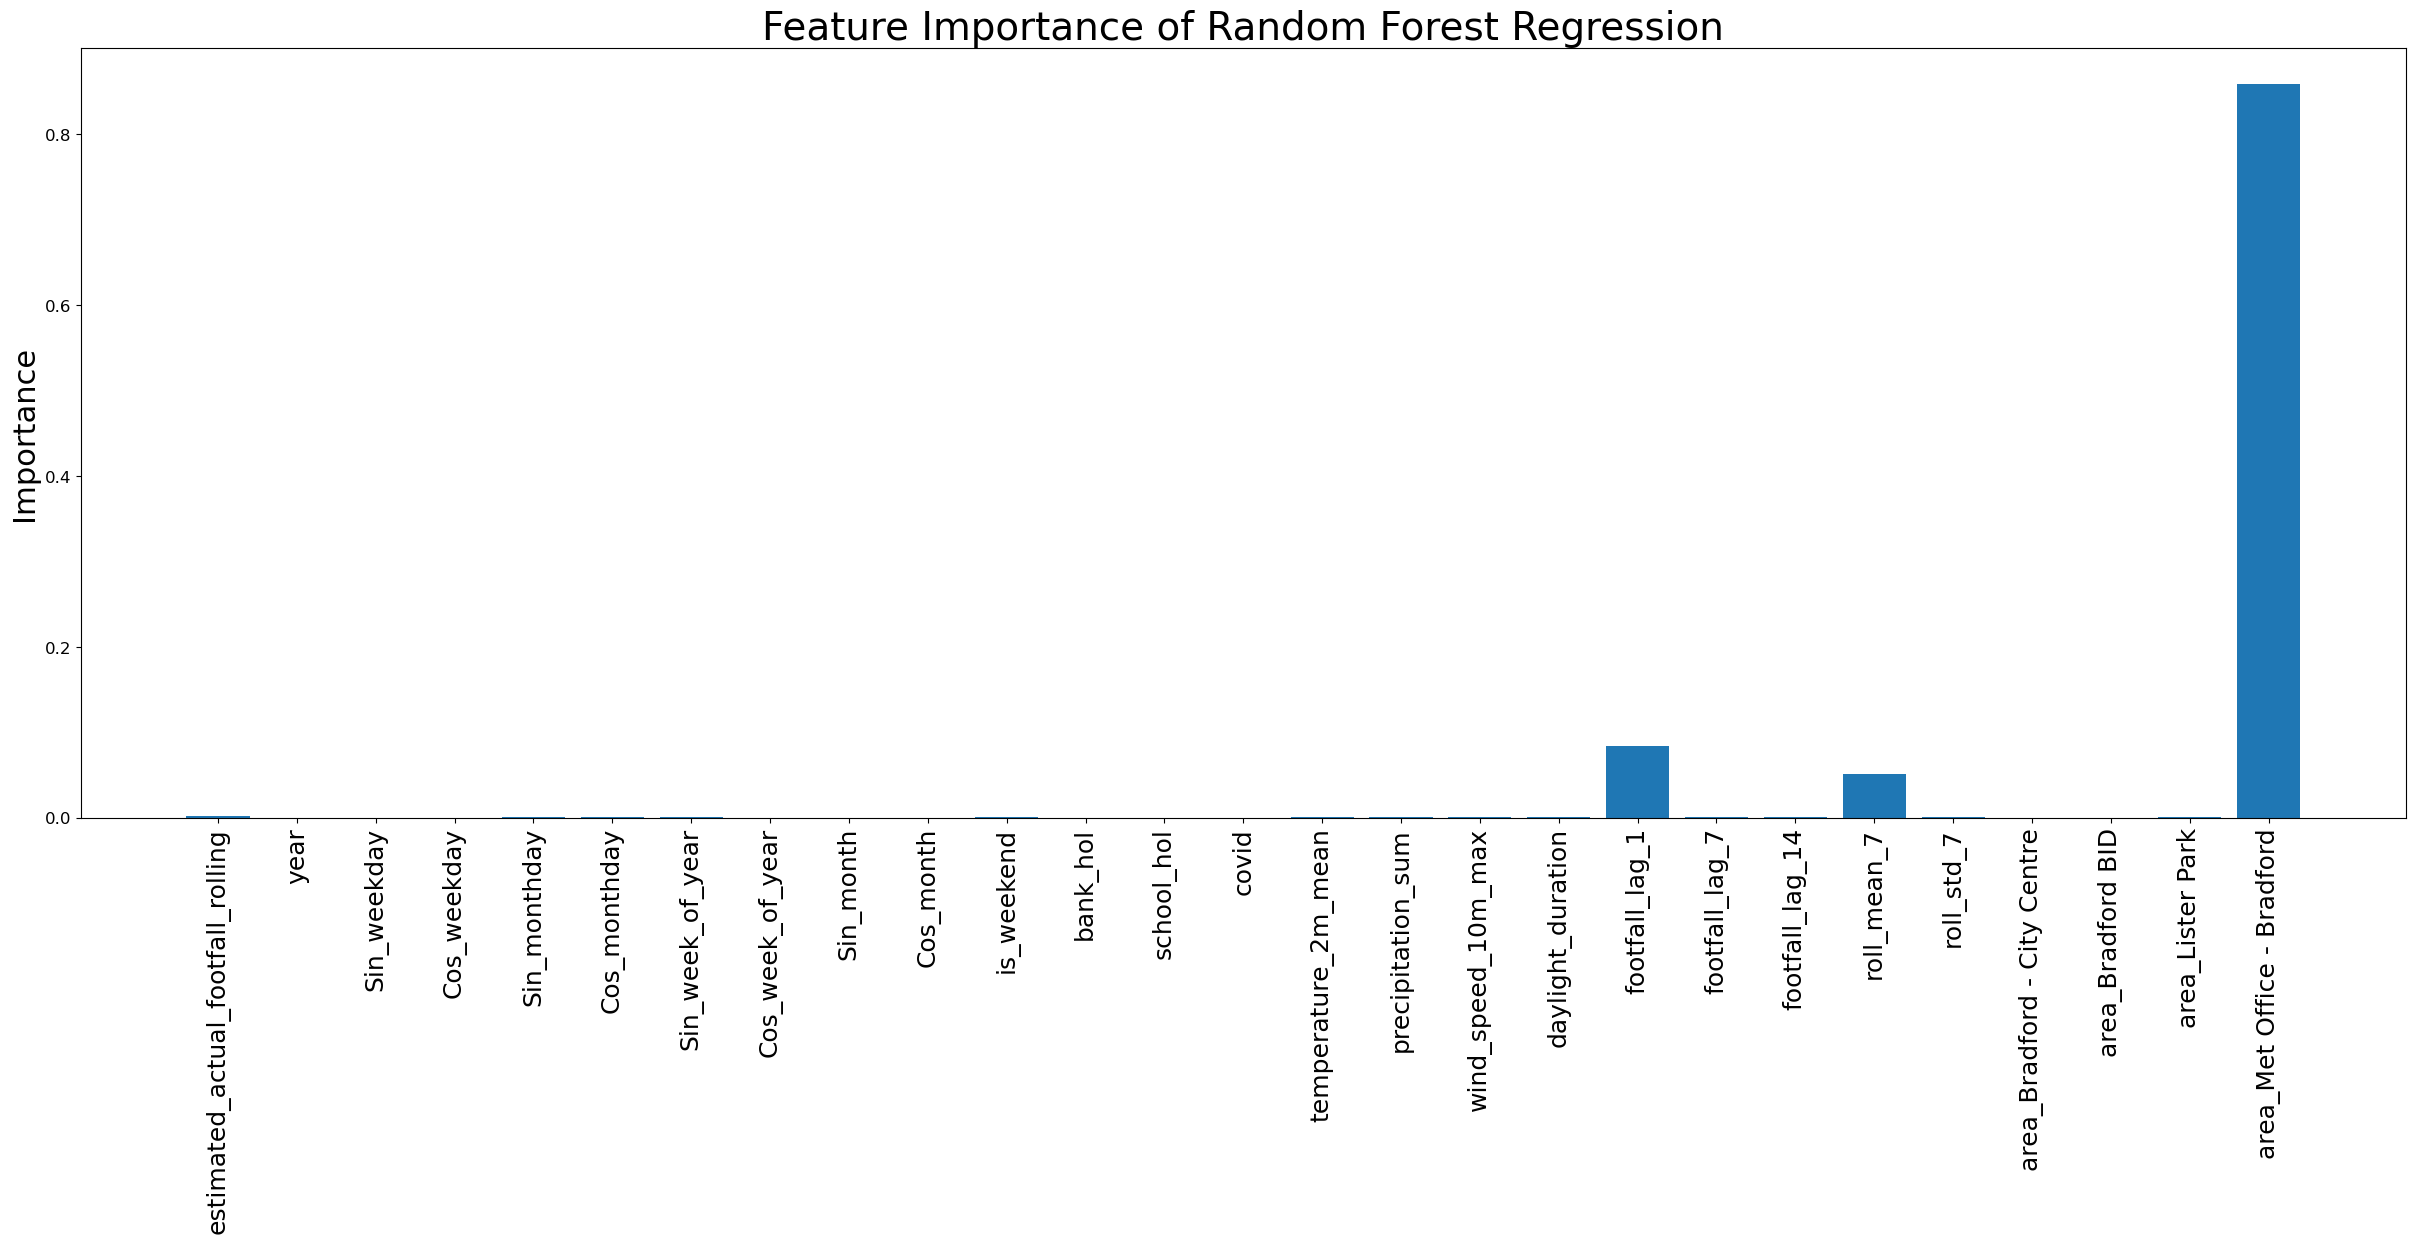

In [318]:
#Extract the rfr model from inside the pipeline
rf_model_final = rfr_pipeline_final.named_steps['rf']
#Extract feature importance from model
importance = rf_model_final.feature_importances_
#Extract feature names
features = Xfull.columns.tolist()

#Plot
plt.figure(figsize=(30, 10))
plt.bar(features, importance)
plt.title('Feature Importance of Random Forest Regression', fontsize= 28)
plt.ylabel('Importance', fontsize= 22)
plt.xticks(rotation=90, fontsize=18)
plt.yticks(size=12)
plt.show()

In [319]:
#Check feature importance values of model
for feat, imp in zip(Xfull.columns, importance):
    print(f"{feat}: {imp:.4f}")

estimated_actual_footfall_rolling: 0.0015
year: 0.0001
Sin_weekday: 0.0001
Cos_weekday: 0.0001
Sin_monthday: 0.0003
Cos_monthday: 0.0002
Sin_week_of_year: 0.0003
Cos_week_of_year: 0.0001
Sin_month: 0.0001
Cos_month: 0.0000
is_weekend: 0.0005
bank_hol: 0.0000
school_hol: 0.0000
covid: 0.0000
temperature_2m_mean: 0.0004
precipitation_sum: 0.0003
wind_speed_10m_max: 0.0003
daylight_duration: 0.0003
footfall_lag_1: 0.0841
footfall_lag_7: 0.0006
footfall_lag_14: 0.0006
roll_mean_7: 0.0506
roll_std_7: 0.0006
area_Bradford - City Centre: 0.0000
area_Bradford BID: 0.0001
area_Lister Park: 0.0002
area_Met Office - Bradford: 0.8585


# 6- Cross-Validated SHAP for Feature Importance Analysis

The SHapley Additive exPlanation (SHAP) method is used to investigate RFR model feature importance.

Cross-validation allows generalization of the model. Results from a simple train/test split are liable to drastic changes based on how the data is partitioned. Timeseries cross-validation is prefered to account for the chronological order of the data. I split the data into 5 folds, and separate each fold into training (fold[0]) and test data (fold[1]).

In [320]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

#Ensure index is time-ordered
Xfull = Xfull.sort_index()
Yfull = pd.Series(Yfull, index= Xfull.index)

In [321]:
#TimeSeriesSplit Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
tscv= TimeSeriesSplit(n_splits= 5)

In [322]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [323]:
#Load SHAP package
import shap
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [324]:
#5-Fold TimeSeries Cross-Validation Loop

#Create empty lists
SHAP_values_per_fold = [] #store shap values

R2_scores = []
mse_scores = []
mae_scores = []
Y_test_all = []
Y_pred_all = []

#Loop though each fold (i)
for fold, (train_idx, test_idx) in enumerate(tscv.split(Xfull), 1):
    #Print fold number (check)
    print(f'Fold Number: {fold}')

    #Split data according to indices into training and test sets
    X_train, X_test = Xfull.iloc[train_idx], Xfull.iloc[test_idx]
    Y_train, Y_test = Yfull.iloc[train_idx], Yfull.iloc[test_idx]

    #Train Random Forest Regression model
    rfr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 300,
                                  max_depth= 10,
                                  min_samples_split= 10,
                                  min_samples_leaf = 4,
                                  max_features= None,
                                  random_state= 1,
                                  bootstrap= True))])
    
    #Fit pipeline
    rfr_pipeline.fit(X_train , Y_train)
    
    #Predict Y using pipeline
    Y_pred = rfr_pipeline.predict(X_test)
    
    #Save the evaluation metrics for each fold and add to list
    R2_scores.append(r2_score(Y_test, Y_pred))
    mse_scores.append(mean_squared_error(Y_test, Y_pred))
    mae_scores.append(mean_absolute_error(Y_test, Y_pred))
    
    #Save the predictions and test values
    Y_test_all.append(Y_test)
    Y_pred_all.append(pd.Series(Y_pred, index= Y_test.index))


    #Extract the trained RF model from the pipeline
    rf_model = rfr_pipeline.named_steps['rf']
    #Scale the test data (because have previously scaled the training data)
    X_test_scaled = rfr_pipeline.named_steps['scaler'].transform(X_test)


    #SHAP values calculation
    #Create Tree Explainer object that can calculate shap values from model
    explainer = shap.TreeExplainer(rf_model)
    #Calculate SHAP values for test dataset of current fold
    shap_values_fold = explainer.shap_values(X_test_scaled)
    #Store SHAP values with their original X indices to ensure alignement
    shap_df_fold = pd.DataFrame(shap_values_fold,
                                columns=Xfull.columns,
                                index= X_test.index)
    #Append each fold 
    SHAP_values_per_fold.append(shap_df_fold)

Fold Number: 1
Fold Number: 2
Fold Number: 3
Fold Number: 4
Fold Number: 5


In [325]:
#Concatenate all shap values and reorder indices to match original X order
shap_df = pd.concat(SHAP_values_per_fold).sort_index()

#Create dataframes with outputs
results_df = pd.DataFrame({
    'Y_test': Y_test_all,
    'Y_pred': Y_pred_all
}).sort_index()

#Metrics per fold (for all 5 folds)
metrics_df = pd.DataFrame({
    'Fold': list(range(len(R2_scores))),
    'R2': R2_scores,
    'MSE': mse_scores,
    'MAE': mae_scores
})

In [326]:
#Check
shap_df

#Note: The TimeSeries takes the first 1465 rows for training sets
# thus their SHAP values aren't computed
# this is normal for time-series cross-validation

,estimated_actual_footfall_rolling,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,...,daylight_duration,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7,area_Bradford - City Centre,area_Bradford BID,area_Lister Park,area_Met Office - Bradford
1465,-213.071561,0.000000,-458.532510,834.456245,-371.631252,346.002783,-548.624230,-1457.458253,-140.242271,-129.733900,...,-2610.137763,-20876.801148,2435.325525,378.784837,6011.151357,204.122350,1804.342391,3862.538000,24805.540829,-98368.966076
1466,-3038.186049,0.000000,-214.377475,319.449806,291.802133,290.267177,-303.996687,-856.805127,-147.023987,-39.274260,...,-1432.468397,-23919.191047,-3102.029249,-1600.161935,-36072.582259,276.630623,828.435828,-1592.911339,-41841.626973,-114194.707027
1467,4509.707778,0.000000,-27.867369,1090.938982,-26.391353,-788.723257,-709.520023,-1095.759253,107.073743,-210.708014,...,-2387.830719,47962.277337,2378.565014,3060.177695,3561.911942,-146.967255,745.462906,-1260.688406,11653.314232,323705.524713
1468,-2205.494381,0.000000,685.602795,477.185743,-89.720293,841.622489,-377.440871,-2023.044505,-221.773543,-180.195046,...,-2366.671805,-22070.063491,-668.603381,-862.117142,-30893.873727,-1245.320226,-1026.831816,-2440.443188,20980.804913,-104701.631465
1469,723.608204,0.000000,696.468789,789.294692,-1233.563063,655.011459,-418.397795,-1410.343332,-193.422047,-106.096688,...,-2532.536259,-20299.849172,2713.847070,2294.016019,5221.980965,-1401.583232,1622.932754,3727.707231,24725.852298,-97511.878804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8775,-9798.278010,227.914536,600.048556,759.787356,-148.723290,-130.282492,26.448162,248.668204,72.504769,-65.051986,...,826.933251,-20151.554054,-7267.238517,-754.557566,22859.082063,1840.210945,252.828712,-313.029341,3507.372433,-101767.815473
8776,-8963.267329,142.192968,80.012858,278.202920,-75.360347,-61.996614,190.076060,-284.527235,-14.670436,-50.211331,...,-124.399611,-22965.428941,-1723.205807,-1619.723291,-32187.138261,-104.686779,244.193953,-92.626128,-2267.214403,-110947.123991
8777,4796.643222,629.152382,-301.671302,-656.690622,-1333.767985,307.931647,407.537215,76.742003,-146.213907,-99.287673,...,628.072369,-14795.303339,-318.806477,862.416143,51308.816967,1088.679089,322.282827,5970.241275,3525.817226,-94191.941321
8778,-5009.988856,142.860486,-488.276608,-1145.382252,-952.239582,-132.668701,43.887244,99.257282,228.266151,-9.615937,...,789.329771,-24080.610505,616.944597,-3298.576384,23744.102058,1061.599890,156.486903,-371.534645,3152.327812,-101222.457916


In [327]:
#Get average metrics over the 5 folds
mae = metrics_df['MAE'].mean()
mse = metrics_df['MSE'].mean()
r2 = metrics_df['R2'].mean()

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 21170.879537169956
Mean Squared Error: 860121315.6147957
R² Score: 0.9863192087262209


Text(676.2548611111112, 0.5, 'Feature Value')

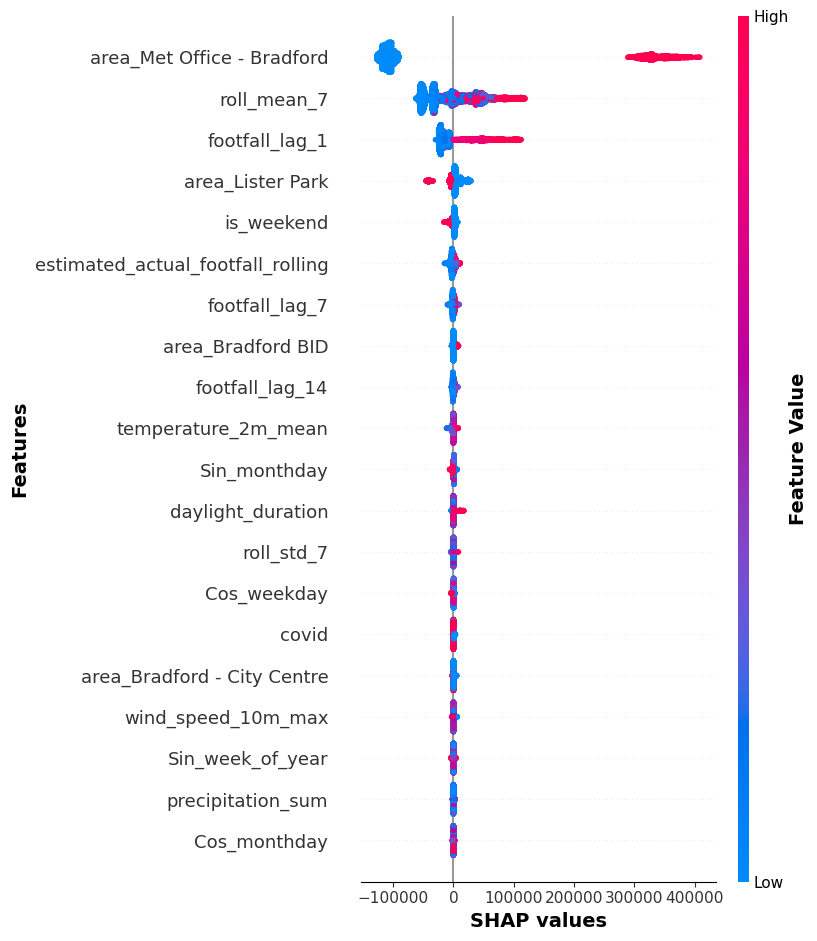

In [328]:
#Plot summary SHAP values
plt.figure(figsize=(40, 10))
shap.summary_plot(shap_df.values, 
                  Xfull.loc[shap_df.index], 
                  show = False)
plt.title('')
plt.xlabel('SHAP values', fontsize=14, weight='bold')
plt.ylabel('Features', fontsize=14, weight='bold')
cbar = plt.gcf().axes[-1] 
cbar.set_ylabel('Feature Value', fontsize=14, weight='bold')

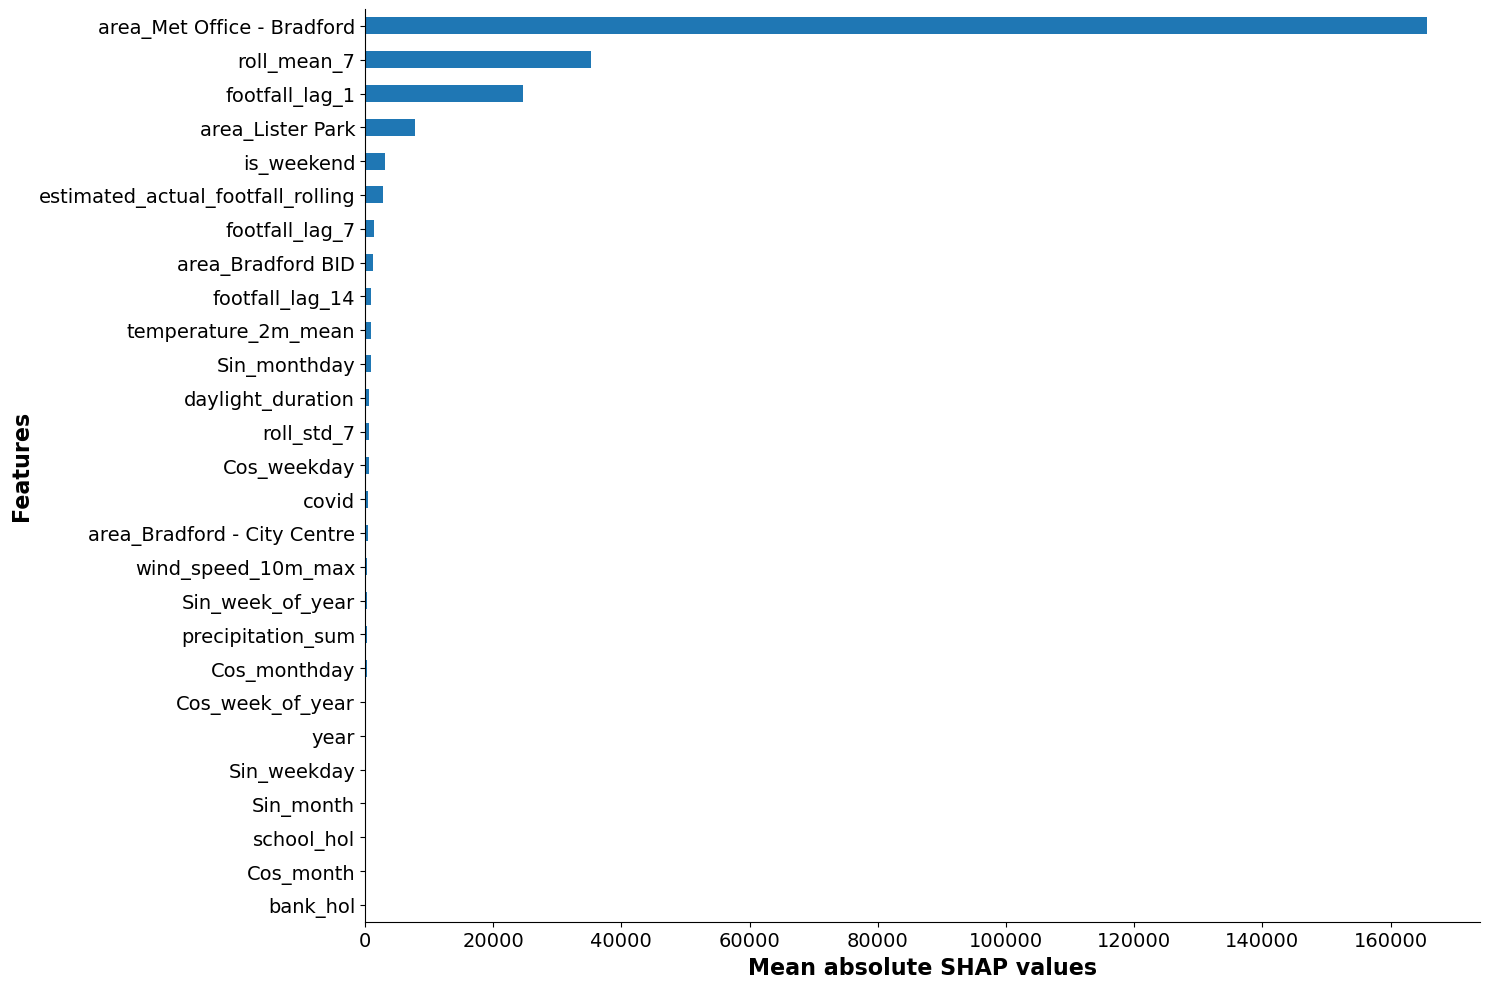

In [329]:
#Plot Mean Absolute SHAP values for each feature
mean_abs_shap = shap_df.abs().mean().sort_values()

#Plot
plt.figure(figsize=(15, 10))
mean_abs_shap.plot(kind='barh')
plt.title('')
plt.xlabel('Mean absolute SHAP values', fontsize=16, weight='bold')
plt.ylabel('Features', fontsize=16, weight='bold')
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [330]:
#Get the absolute mean SHAP values
mean_abs_shap

bank_hol                                 25.163485
Cos_month                                58.224917
school_hol                              101.855922
Sin_month                               120.067464
Sin_weekday                             194.230349
year                                    201.515706
Cos_week_of_year                        236.700748
Cos_monthday                            290.854388
precipitation_sum                       319.830239
Sin_week_of_year                        353.361770
wind_speed_10m_max                      368.092224
area_Bradford - City Centre             429.334102
covid                                   500.015876
Cos_weekday                             620.019684
roll_std_7                              630.556319
daylight_duration                       693.632434
Sin_monthday                            879.785242
temperature_2m_mean                     958.172372
footfall_lag_14                         987.735875
area_Bradford BID              

# 7- Using RFR model to evaluate events, with Recursive Forecasting

Now that the final Random Forest Regression has been trained on the footfall data between 2019 and 2024, the model is used to predict what footfall should have looked like in 2025 without any events, thus without the Bradford 2025 City of Culture program. Comparing the predicted vs the actual footfall values allows to access the success of the program by using footfall as a proxy.

A recursive forecasting technique is used. The Random Forest Regression model was trained using the lagged and rolling footfall as a features. However, to keep the model blind to the fact that events were occuring, these predictors of the 2025 data are not fed into the model (only the contextual temporal and weather variables). Instead, the model uses its own predicted footfall values from previous time steps as input, to calculate the lagged and rolling footfall itself.

In [331]:
#Load historical footfall (2019-2024) data again
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - All areas\footfall_cleaned_19_24")
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'monthday', 'weekday', 'week_of_year'], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8780 entries, 0 to 8779
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          8780 non-null   object 
 1   estimated_actual_footfall          8780 non-null   float64
 2   estimated_actual_footfall_rolling  8612 non-null   float64
 3   year                               8780 non-null   int64  
 4   Sin_weekday                        8780 non-null   float64
 5   Cos_weekday                        8780 non-null   float64
 6   Sin_monthday                       8780 non-null   float64
 7   Cos_monthday                       8780 non-null   float64
 8   Sin_week_of_year                   8780 non-null   float64
 9   Cos_week_of_year                   8780 non-null   float64
 10  Sin_month                          8780 non-null   float64
 11  Cos_month                          8780 non-null   float

In [332]:
#Get data to make prediction on -> the 2025 footfall data
data_2025 = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - All areas\footfall_cleaned_2025")
#For time series analysis, the data needs to be in chronological order
# thus there is a need to reset the indexes based on datestamp
data_2025 = data_2025.sort_values('datestamp')
data_2025 = data_2025.reset_index(drop=True)
#Check
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         1373 non-null   int64  
 1   datestamp                          1373 non-null   object 
 2   estimated_actual_footfall          1209 non-null   float64
 3   estimated_actual_footfall_rolling  1174 non-null   float64
 4   year                               1373 non-null   int64  
 5   month                              1373 non-null   int64  
 6   monthday                           1373 non-null   int64  
 7   weekday                            1373 non-null   int64  
 8   week_of_year                       1373 non-null   int64  
 9   Sin_weekday                        1373 non-null   float64
 10  Cos_weekday                        1373 non-null   float64
 11  Sin_monthday                       1373 non-null   float

In [333]:
data_2025.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7,area_name,area_Bradford - City Centre,area_Bradford BID,area_Lister Park,area_Met Office - Bradford
0,8768,2025-01-01,44668.28,90717.643333,2025,1,1,2,1,8.660254e-01,...,44488.55,86316.40,69634.51,81747.110000,36356.725381,Bradford - City Centre,1,0,0,0
1,8769,2025-01-01,151088.86,176836.396667,2025,1,1,2,1,8.660254e-01,...,133690.66,186023.94,148326.56,182215.454286,37318.376709,Bradford BID,0,1,0,0
2,8770,2025-01-01,35005.45,44095.925000,2025,1,1,2,1,8.660254e-01,...,8679.53,46976.28,40064.54,35526.200000,16343.632561,Lister Park,0,0,1,0
3,8771,2025-01-01,577601.00,601809.666667,2025,1,1,2,1,8.660254e-01,...,599590.00,589465.00,606494.00,593084.142857,11788.645334,Met Office - Bradford,0,0,0,1
4,8772,2025-01-02,94132.25,78075.401667,2025,1,2,3,1,1.224647e-16,...,44668.28,113925.98,43392.64,75797.378571,38809.438236,Bradford - City Centre,1,0,0,0


In [334]:
#Drop columns that are not variables used in the analysis
data_2025.drop(['Unnamed: 0', 'month', 'monthday', 'weekday', 'week_of_year'], axis=1, inplace=True)

#Drop rows with no estimated_actual_footfall (won't allow comparison with predicted values)
data_2025 = data_2025.dropna(subset=['estimated_actual_footfall'])
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1209 entries, 0 to 1372
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          1209 non-null   object 
 1   estimated_actual_footfall          1209 non-null   float64
 2   estimated_actual_footfall_rolling  1160 non-null   float64
 3   year                               1209 non-null   int64  
 4   Sin_weekday                        1209 non-null   float64
 5   Cos_weekday                        1209 non-null   float64
 6   Sin_monthday                       1209 non-null   float64
 7   Cos_monthday                       1209 non-null   float64
 8   Sin_week_of_year                   1209 non-null   float64
 9   Cos_week_of_year                   1209 non-null   float64
 10  Sin_month                          1209 non-null   float64
 11  Cos_month                          1209 non-null   float64
 1

The rolling and lagged features are not supposed to be seen by the model, except for the first day/week of that, as these lagged and rolling values will be based on known 2024 data. Thus, we need to keep the values based on known 2024 data, but replace all values that the model shouldn't see by NaNs.

In [335]:
#Footfall lag/rolling features that depend on the previous day
#Keep only first row (index 0), blank the rest
data_2025.loc[1:, ['footfall_lag_1', 'roll_mean_7', 'roll_std_7']] = np.nan

#Footfall lag/rolling features that depend on the previous week
#Keep only first week (indexes 0-6), blank the rest
data_2025.loc[7:, ['estimated_actual_footfall_rolling', 'footfall_lag_7', 'footfall_lag_14']] = np.nan

In [336]:
#Prepare data for modelling
Xfull = data_2025.drop(['estimated_actual_footfall'], axis =1) #Predictor variables
Yfull = data_2025['estimated_actual_footfall'].values #target variable

In [337]:
#Create function to calculate the estimated_actual_footfall_rolling
# for recursive forecasting
# this needs to take into account area of the row

def calculate_estimated_rolling(df, date, area):
    weekday= date.weekday()
    #Filter all 6 past rows with same weekday
    past_same_weekday = (
        df[
            (df['area_name'] == area) &
            (df['datestamp'] < date) &
            (df['datestamp'].dt.weekday == weekday)]
        .sort_values('datestamp')
        .tail(6))

    #Not enough historical data
    if len(past_same_weekday) == 0:
        return None

    #Get average of previous 6 values for the day of the week
    else:
        return past_same_weekday['estimated_actual_footfall'].mean()

In [338]:
#Create function to calculate the lagged and rolling features
# for recursive forecasting
# this needs to take into account area of the row

def calculate_lag_rolling(df, date, area):
    past = (
        df[(df['area_name'] == area) & (df['datestamp'] < date)]
        .sort_values('datestamp')
    )
    
    #Not enough historical data
    if len(past) == 0:
        return np.na #not enough data
    
    features= {}
    
    #Lag features
    features['footfall_lag_1'] = past.iloc[-1]['estimated_actual_footfall'] if len(past) >= 1 else np.na
    features['footfall_lag_7'] = past.iloc[-7]['estimated_actual_footfall'] if len(past) >= 7 else np.na
    features['footfall_lag_14'] = past.iloc[-14]['estimated_actual_footfall'] if len(past) >= 14 else np.na
    
    #Rolling features
    tail7 = past['estimated_actual_footfall'].tail(7)
    features['roll_mean_7'] = tail7.mean() if len(tail7) > 0 else np.na
    features['roll_std_7'] = tail7.std() if len(tail7) > 0 else np.na
    
    #Weekday-based rolling
    features['estimated_actual_footfall_rolling'] = calculate_estimated_rolling(df, date, area)
    
    return features
    

In [339]:
#Define columns with lag/rolling values
lag_roll_cols = ['footfall_lag_1', 
                 'footfall_lag_7', 
                 'footfall_lag_14', 
                 'roll_mean_7', 
                 'roll_std_7',
                 'estimated_actual_footfall_rolling']

In [340]:
#Recursive forecasting function

"""
Recursive forecasting for future footfall

model: is the previously trained Random Forest Regressor model
history_df: is the data with historical data, used to previously train the model (2019-2024)
future_df: is the data (2025) we want to predict the footfall for
            but exclude the lagged and rolling footfall
            include the 'datestamp' and 'estimated_actual_footfall' for comparison with model predictions
feature_cols: list of features used to train the model (excludes datestamp)

"""

def recursive_forecast(model, history_df, future_df, feature_cols):

    #Store footfall predictions
    predictions = []
    #Store recursive features values
    feature_rows = []
    
    areas = history_df['area_name'].unique()
    
    #Recursive forecasting must be done per area
    for area in areas:
            #Filter history and future for this area only
            hist_area = history_df[history_df['area_name'] == area].copy()
            future_area = future_df[future_df['area_name'] == area].copy()
            
            #Copy of history for this area (2019-2024 + previous predictions as loop runs)
            history = hist_area.copy()
            
            for idx, row in future_area.iterrows():
                row_copy = row.copy()
                date = row['datestamp']

#-------------------------------------------------------------------------------------------------------
        
                #Step 1: Keep precomputed rolling/lag values if present
                #and calculate them based on predictions if absent, as function runs along
                missing = row_copy[lag_roll_cols].isna().any()
                if missing:
                        lag_roll_feats = calculate_lag_rolling(history, date, area)
                        if lag_roll_feats is not None:
                                for k, v in lag_roll_feats.items():
                                        row_copy[k] = v

#------------------------------------------------------------------------------------------------------------------

                #Step 2: Make Footfall prediction

                # Select only the features in the row used for modelling
                X_row = row_copy[feature_cols].to_frame().T

                #Use model to predict footfall
                y_pred = model.predict(X_row)[0]

#------------------------------------------------------------------------------------------------------------------

                #Step 3: Update history for next step

                #Add this prediction into history for future lagged/rolling values
                new_history_row = row_copy.copy()
                new_history_row['estimated_actual_footfall'] = y_pred
                history = pd.concat([history, pd.DataFrame([new_history_row])], ignore_index= True)

#------------------------------------------------------------------------------------------------------------------

                #Step 4: Store recursive features separately (with area info)
                feature_rows.append({
                        'datestamp': date, 
                        **{k: row_copy[k] for k in lag_roll_cols}
                        })
#------------------------------------------------------------------------------------------------------------------

                #Step 5: Store model predictions    
                #with date and area info along with prediction
                predictions.append({
                        'datestamp': date,
                        'area_name': area,
                        'predicted_footfall': y_pred,
                        })
    
    
    predictions_df = pd.DataFrame(predictions)
    recursive_features_df = pd.DataFrame(feature_rows)
    return predictions_df , recursive_features_df

In [347]:
#Define the list of features used in model training
features = ['estimated_actual_footfall_rolling', 
            'year', 
            'Sin_weekday',
            'Cos_weekday',
            'Sin_monthday',
            'Cos_monthday', 
            'Sin_week_of_year', 
            'Cos_week_of_year',
            'Sin_month',
            'Cos_month', 
            'is_weekend', 
            'bank_hol',
            'school_hol', 
            'covid', 
            'temperature_2m_mean',
            'precipitation_sum', 
            'wind_speed_10m_max', 
            'daylight_duration',
            'footfall_lag_1',
            'footfall_lag_7',
            'footfall_lag_14',
            'roll_mean_7',
            'roll_std_7',
            'area_Bradford - City Centre',
            'area_Bradford BID', 
            'area_Lister Park', 
            'area_Met Office - Bradford'
            ]

In [348]:
#Ensure the datestamp columns of both datasets are datetime
data_2025['datestamp'] = pd.to_datetime(data_2025['datestamp'])
data['datestamp'] = pd.to_datetime(data['datestamp'])

The recursive forecasting fucntion with the Random Forest Regression model is called to create footfall predictions for 2025:

In [349]:
#Call the recursive forecasting function
predictions_2025, recursive_features_2025 = recursive_forecast(rf_model_final,
                                      data,
                                      data_2025,
                                      features)

predictions_2025.info()

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datestamp           1209 non-null   datetime64[ns]
 1   area_name           1209 non-null   object        
 2   predicted_footfall  1209 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 28.5+ KB


c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\ProgramData\anaconda3\envs\

The actual 2025 footfall values are fetched and merged with the predictions.

In [353]:
#Add the actual values to the predictions
data_2025['datestamp'] = pd.to_datetime(data_2025['datestamp'])
predictions_2025['datestamp'] = pd.to_datetime(predictions_2025['datestamp'])

predictions_2025 = predictions_2025.merge(
    data_2025[['datestamp', 'estimated_actual_footfall', 'area_name']],
    on=['datestamp', 'area_name'],
    how='left')

#Check there are 1209 rows
predictions_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   datestamp                  1209 non-null   datetime64[ns]
 1   area_name                  1209 non-null   object        
 2   predicted_footfall         1209 non-null   float64       
 3   estimated_actual_footfall  1209 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 37.9+ KB


In [357]:
predictions_2025.head()

,datestamp,area_name,predicted_footfall,estimated_actual_footfall
0,2025-01-01,Bradford - City Centre,272741.911243,44668.28
1,2025-01-02,Bradford - City Centre,247668.427816,94132.25
2,2025-01-03,Bradford - City Centre,253633.096228,131319.63
3,2025-01-04,Bradford - City Centre,248904.114418,77140.71
4,2025-01-05,Bradford - City Centre,252716.190850,80344.60


Visualize prediction vs actual footfall values in 2025, for each of the 4 areas. To do so calculate the percentage increase between the prediction and actual footfall.

In [358]:
#Calculate the percentage increase
predictions_2025['Percentage_Increase'] = ((predictions_2025['estimated_actual_footfall'] - predictions_2025['predicted_footfall']) / abs(predictions_2025['predicted_footfall'])) * 100

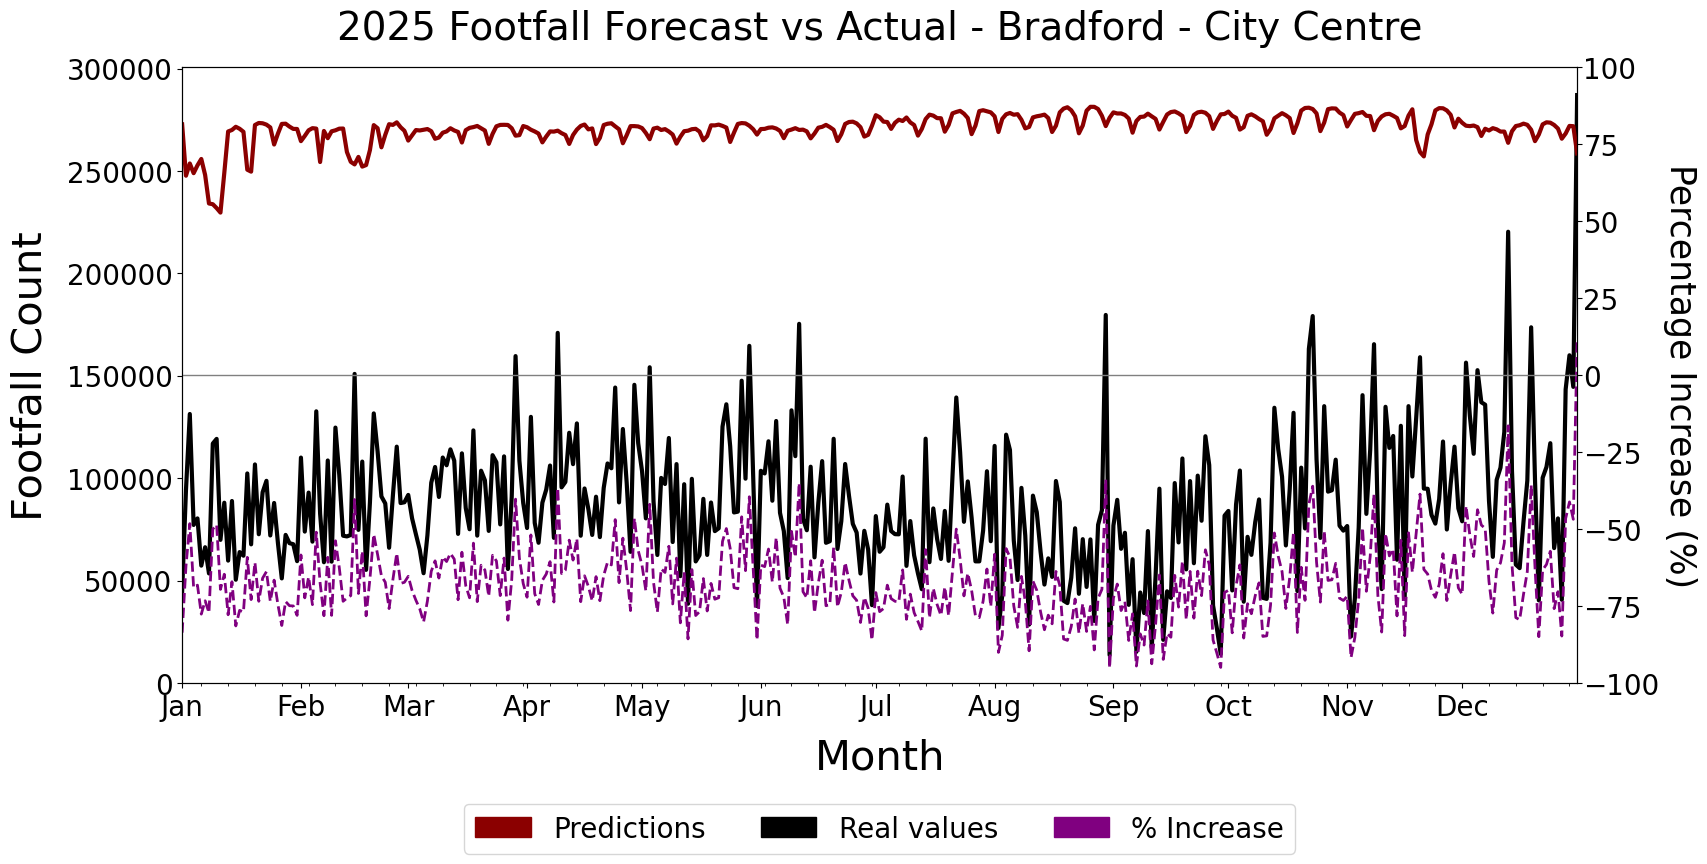


Summary stats for Bradford - City Centre


count    365.000000
mean     -67.437367
std       12.618744
min      -95.068228
25%      -75.154341
50%      -68.607885
75%      -60.579486
max       11.016318
Name: Percentage_Increase, dtype: float64

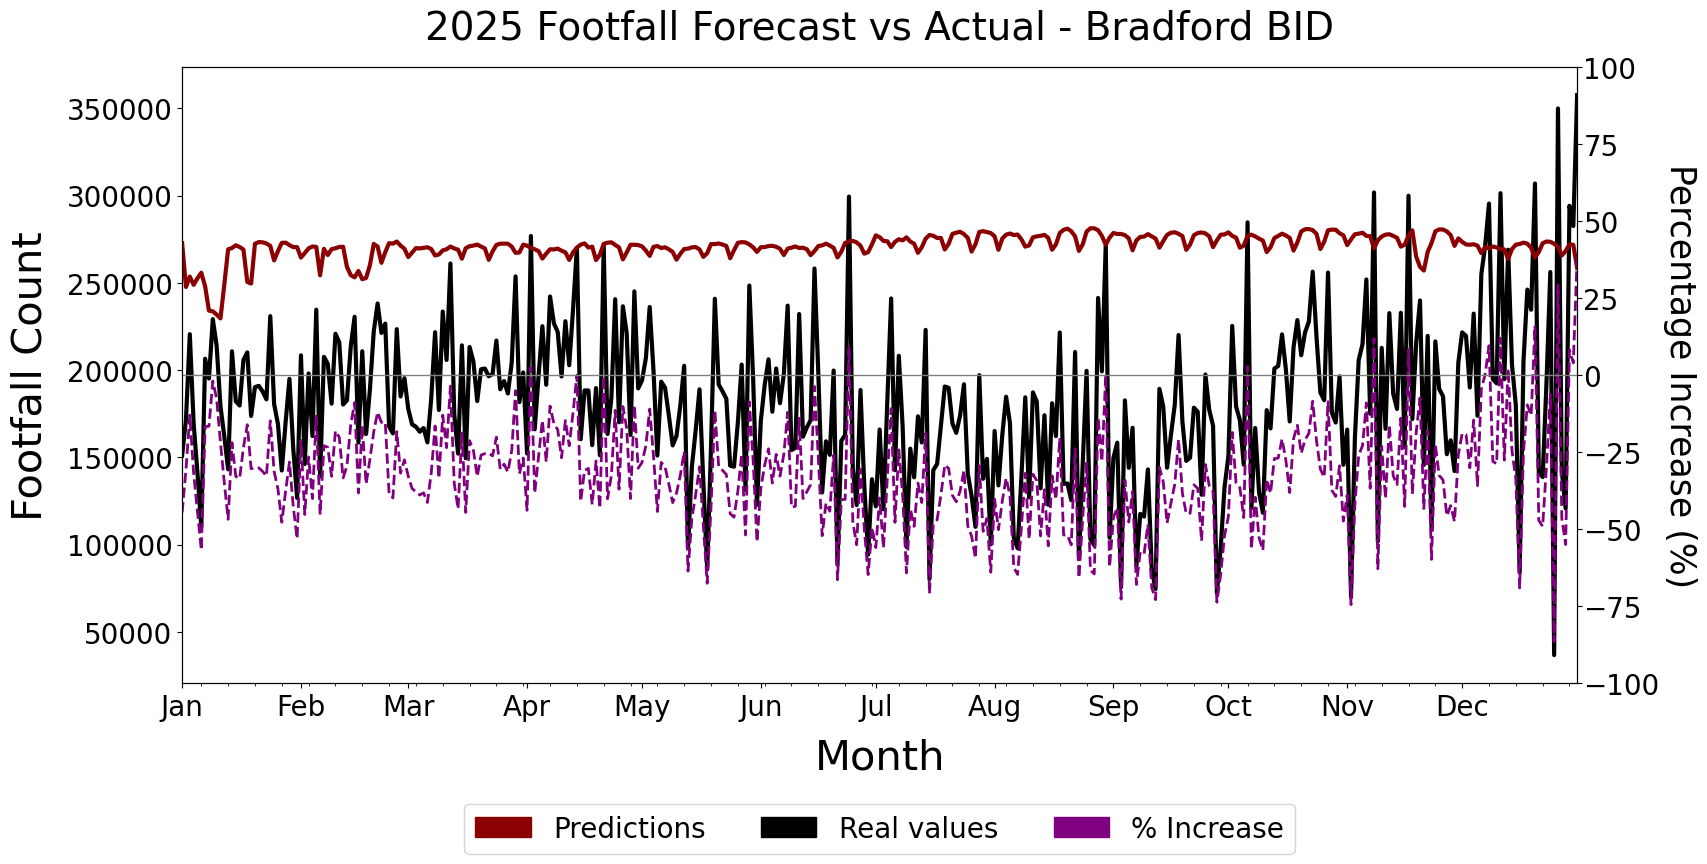


Summary stats for Bradford BID


count    365.000000
mean     -32.780997
std       17.617719
min      -86.505543
25%      -43.316209
50%      -32.855008
75%      -22.948692
max       38.319122
Name: Percentage_Increase, dtype: float64

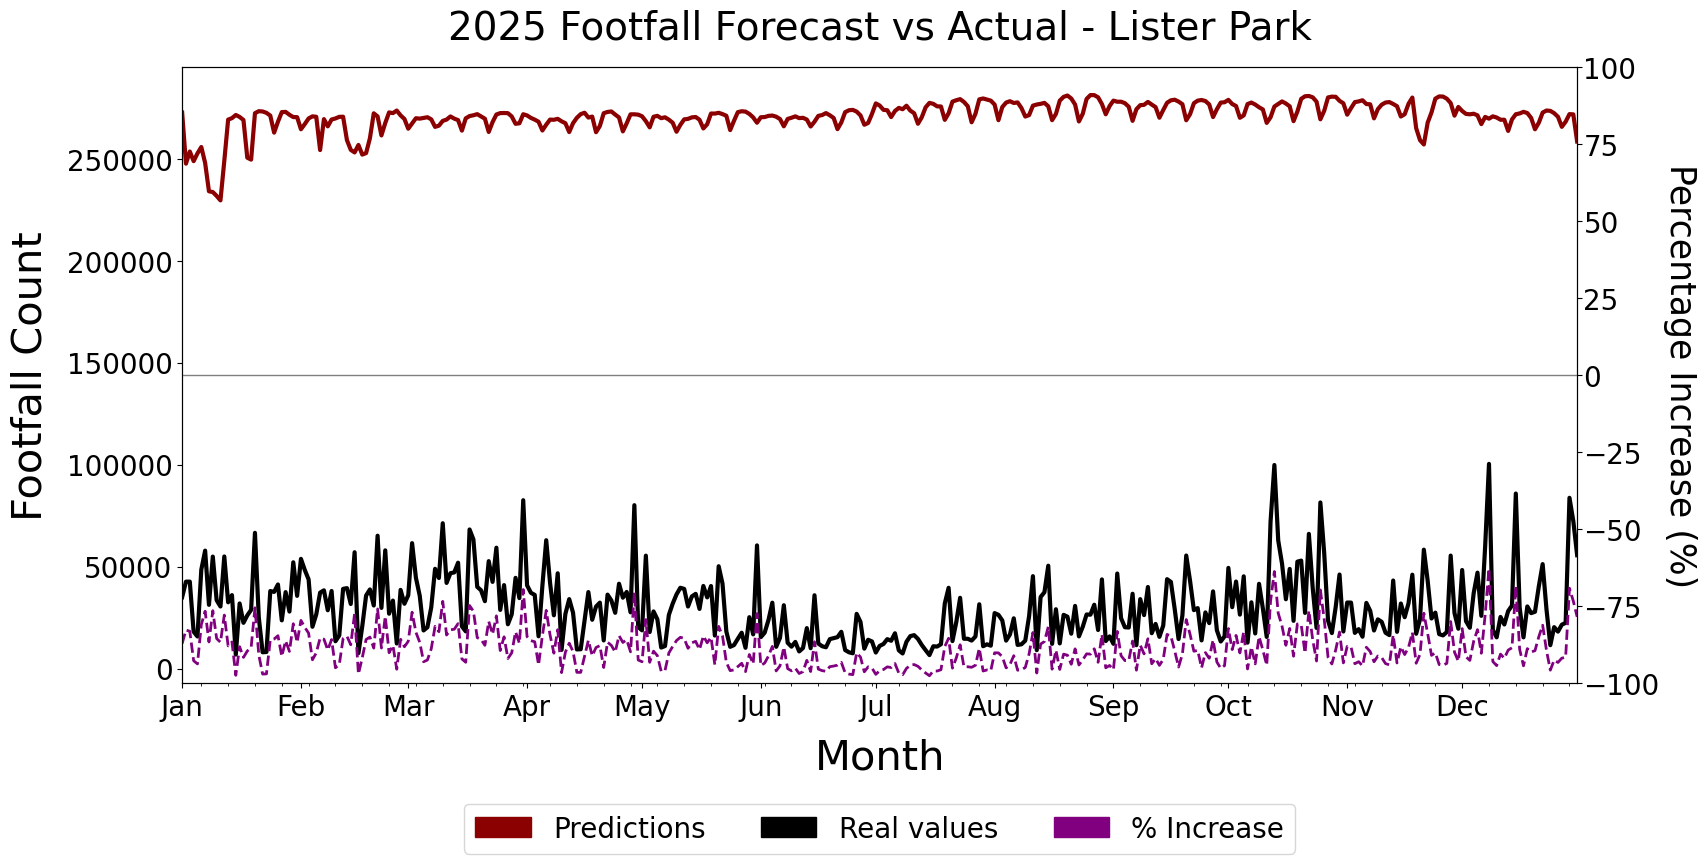


Summary stats for Lister Park


count    365.000000
mean     -88.927025
std        6.208384
min      -97.613514
25%      -93.978476
50%      -89.979717
75%      -85.550094
max      -62.777214
Name: Percentage_Increase, dtype: float64

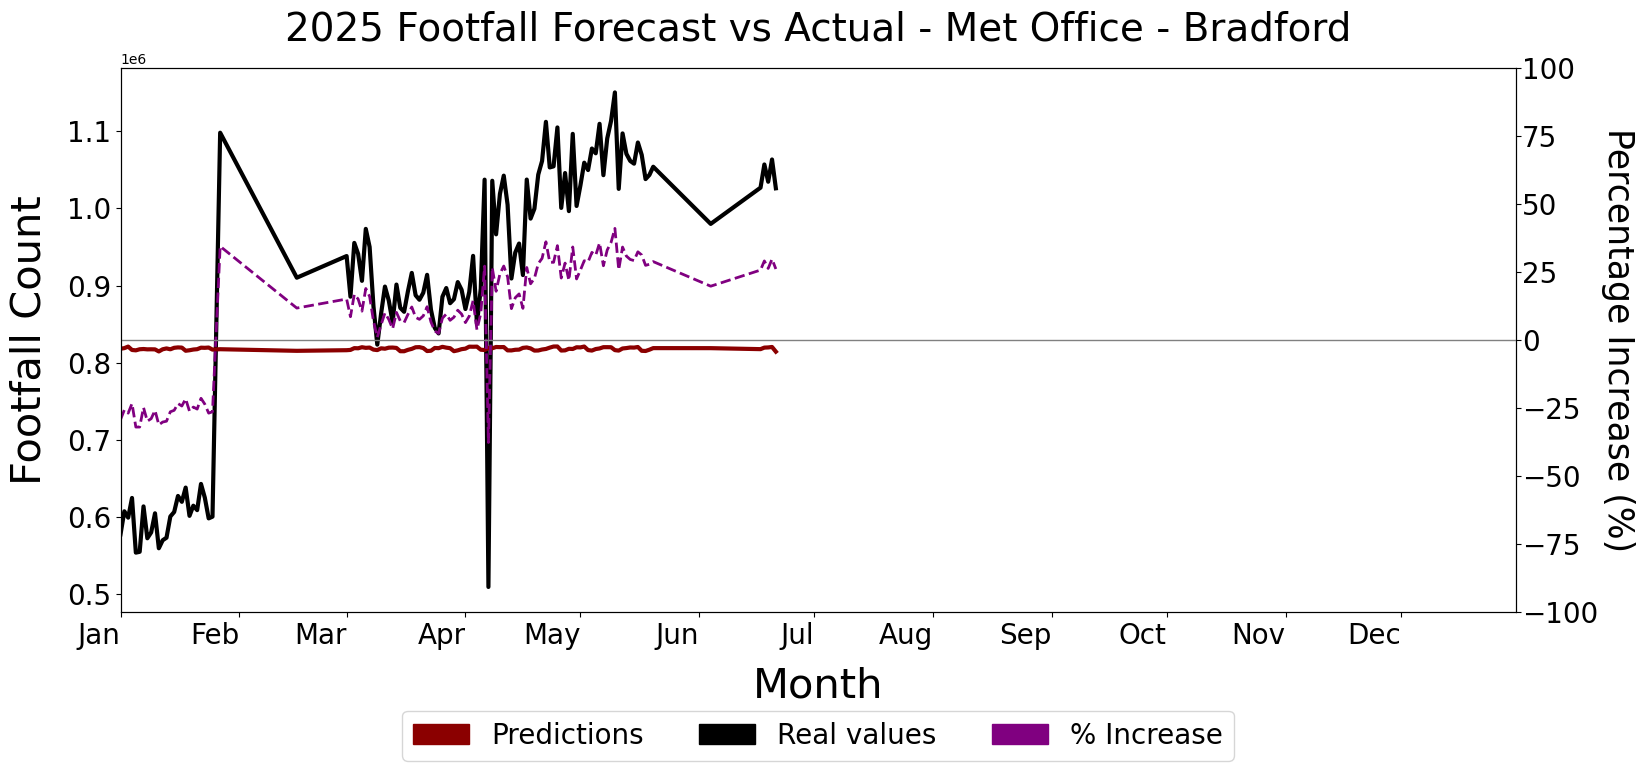


Summary stats for Met Office - Bradford


count    114.000000
mean       8.936128
std       21.820107
min      -37.800056
25%        3.284449
50%       11.825622
75%       27.154097
max       40.916061
Name: Percentage_Increase, dtype: float64

In [361]:
#Plot actual footfall, predicted footfall, and percentage increase between the two for comparison
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.pyplot as plt


#Ensure datestamp is datetime
predictions_2025['datestamp'] = pd.to_datetime(predictions_2025['datestamp'])

include_percent_increase = True
areas = predictions_2025['area_name'].unique()

#Loop through areas to create interactive plot
for area in areas:
    df_r = predictions_2025[predictions_2025['area_name'] == area].copy()

    fig, ax = plt.subplots(figsize = (18,8))

    #Plot actual and predicted footfall
    df_r.plot(x='datestamp', y='estimated_actual_footfall', ax=ax, color='black', linewidth=3, legend =False)
    df_r.plot(x='datestamp', y='predicted_footfall', ax=ax, color='darkred', linewidth=3, legend =False)

    #Plot percentage increase on secondary axis
    if include_percent_increase==True:
        ax2 = ax.twinx()
        df_r.plot(x='datestamp', y='Percentage_Increase', ax=ax2, color='purple', linewidth=2, legend =False, linestyle = 'dashed')
        ax2.set_ylabel('Percentage Increase (%)', fontsize=25, rotation=270, labelpad=27)
        ax2.tick_params(axis='both', which='major', labelsize=20, pad=1)
        ax2.set_ylim(-100,100)

    #Set x axis to show month names, and tick parameters
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    #Force x axis to start in Jan and end in December
    ax.set_xlim([pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31')])
    ax.tick_params(axis='x', labelsize=20, rotation=0)
    ax.tick_params(axis='y', labelsize=20)

    #Set labels of axes
    ax.set_xlabel('Month', fontsize = 30, labelpad=12)
    ax.set_ylabel ('Footfall Count',fontsize=30, labelpad=12)

    #Title
    ax.set_title(f'2025 Footfall Forecast vs Actual - {area}', fontsize=28, pad=20)
    #Legend
    colors_leg = ['darkred', 'black', 'purple']
    texts = ['Predictions', 'Real values','% Increase'] 
    patches = [ mpatches.Patch(color=colors_leg[i], label="{:s}".format(texts[i]) ) for i in range(len(texts)) ]    

    plt.axhline(y = 0, color = 'grey', linestyle = '-', linewidth=1)     
    plt.legend(handles=patches, bbox_to_anchor=(0.5 , -0.3), loc='lower center', ncol=3, prop={'size': 20});

    plt.show()
    
    #Print stats
    print(f'\nSummary stats for {area}')
    display(df_r['Percentage_Increase'].describe())

Note: the model seems to be overpredicting footfall, as there is only a % increase in footfall when comparing prediction and actual footfall in 2025 HOWEVER there was a % increase in actual footfall between 2024 and 2025, thus % seems very small.

In [364]:
areas = predictions_2025['area_name'].unique()

#Loop through areas to get stats
for area in areas:
    df_r = predictions_2025[predictions_2025['area_name'] == area].copy()

    #Get the monthly %increase averages to see which month were most affected by the Bradford25 events
    monthly_2025 = df_r.groupby(predictions_2025['datestamp'].dt.month)['Percentage_Increase'].mean()
    print(f'\nMonhtly Percent Increase stats for {area}')
    print(monthly_2025)


Monhtly Percent Increase stats for Bradford - City Centre
datestamp
1    -69.835795
2    -65.297827
3    -65.296271
4    -62.782200
5    -65.607410
6    -67.088521
7    -71.514121
8    -74.934514
9    -77.085674
10   -67.489772
11   -64.741848
12   -57.430260
Name: Percentage_Increase, dtype: float64

Monhtly Percent Increase stats for Bradford BID
datestamp
1    -30.422433
2    -26.132671
3    -28.111408
4    -23.802560
5    -35.580242
6    -35.476479
7    -42.722021
8    -42.764407
9    -47.124808
10   -30.846936
11   -31.120996
12   -18.830093
Name: Percentage_Increase, dtype: float64

Monhtly Percent Increase stats for Lister Park
datestamp
1    -86.845309
2    -87.040537
3    -84.240140
4    -88.034271
5    -89.460630
6    -94.134243
7    -94.355833
8    -91.377150
9    -90.194519
10   -85.172797
11   -89.979671
12   -86.320658
Name: Percentage_Increase, dtype: float64

Monhtly Percent Increase stats for Met Office - Bradford
datestamp
1   -24.405661
2    11.622155
3     9.059872